# v5 — Adding a Feed-Forward Layer

This builds directly on **v4**. Steps 1–10 below carry over as-is (imports, hyperparameters, data, tokenizer, split, batching, loss estimation, the `Head` and `MultiHeadAttention` classes).

What's new:

1. A `FeedForward` module: a small per-token MLP (`Linear -> ReLU`) applied independently to every position. Attention lets tokens *gather* information from each other; the feed-forward layer lets each token *process* what it gathered.
2. `BigramLanguageModel` now applies `self.feedforward` right after `self.att_head`, before the `linear_head` projects to logits.

## 1. Imports

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

In [ ]:
# emb_size = 32        # embedding size for each token
# batch_size = 32      # how many independent sequences will we process in parallel?
# block_size = 8       # what is the maximum context length for predictions?
# max_iters = 10000    # maximum number of iterations for training
# eval_interval = 500  # interval for evaluating the model
# learning_rate = 1e-3 # learning rate for training
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200     # number of iterations for evaluation
# seed = 42            # seed for reproducibility

# torch.manual_seed(seed)

In [2]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly
import os

emb_size = 32        # embedding size for each token
batch_size = 32      # how many independent sequences will we process in parallel?
block_size = 8       # what is the maximum context length for predictions?
max_iters = 10000    # maximum number of iterations for training
eval_interval = 500  # interval for evaluating the model
learning_rate = 1e-3 # learning rate for training
eval_iters = 200     # number of iterations for evaluation
seed = 42            # seed for reproducibility

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

In [3]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


## 4. Tokenization: characters as tokens

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


In [5]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

In [7]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [8]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([32, 8])
tensor([[54, 60, 57,  0, 52, 54, 59, 47],
        [ 0, 52, 40, 64,  0, 58, 59, 48],
        [44, 58, 58, 54, 57,  0, 15, 51],
        [58, 40, 48, 43,  0, 19, 44, 44],
        [58, 59, 60, 43, 44, 53, 59, 58],
        [57, 40, 48, 59,  0, 58, 62, 60],
        [ 0, 40, 42, 42, 54, 52, 55, 40],
        [ 0, 40, 58,  0, 47, 44,  0, 43],
        [40, 50, 48, 53, 46,  0, 54, 60],
        [48, 58,  0, 48, 53,  0, 45, 40],
        [51, 40, 55,  0, 55, 60, 57, 57],
        [59,  0, 47, 48, 58,  0, 55, 54],
        [57, 44,  0, 47, 40, 43,  0, 59],
        [21, 40, 57, 57, 64,  0,  2, 27],
        [41, 51, 48, 53, 50, 48, 53, 46],
        [ 0, 41, 54, 64,  0, 47, 44, 58],
        [47, 54,  0, 62, 40, 58,  0, 58],
        [44,  0, 58, 52, 48, 57, 50, 44],
        [ 0, 59, 47, 44, 64,  0, 55, 40],
        [40, 57, 57, 64,  0, 51, 40, 60],
        [40, 51, 51, 64,  0, 21, 40, 46],
        [59,  0, 52, 44,  0, 52, 54, 58],
        [47, 40, 61, 44,  0, 43, 57, 40],
      

## 7. Estimating loss

In [9]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. Self-attention head (recap)

In [10]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(emb_size, head_size, bias=False)
        self.query = nn.Linear(emb_size, head_size, bias=False)
        self.value = nn.Linear(emb_size, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        key = self.key(x) # (B,T,H)
        query = self.query(x) # (B,T,H)

        # compute the attention weights
        dot_products = query @ key.transpose(-2,-1) * C**-0.5 # (B,T,H) @ (B,H,T) = (B,T,T) # scale by sqrt(d_k)
        dot_products = dot_products.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mask out the upper triangular part
        weights = F.softmax(dot_products, dim=-1) # (B,T,T) Apply softmax to get the attention weights

        # apply the attention weights to the values
        value = self.value(x) # (B,T,H)
        out = weights @ value # (B,T,T) @ (B,T,H) = (B,T,H)
        return out

## 9. Multi-head attention (recap)

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

## 10. Feed-forward layer — what's new

Attention is the only place tokens exchange information with each other. The feed-forward network is applied independently to each position — it gives the model some per-token compute to make use of what attention just gathered.

**In class:** fill in the part marked **NEW** below.

In [15]:
class FeedForward(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        # NEW: a small per-token MLP -- linear projection followed by a ReLU nonlinearity
        self.net = nn.Sequential(
            nn.Linear(emb_size, emb_size),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

## 11. The model — what's new

`BigramLanguageModel` gets one new attribute, `self.feedforward`, and one new line in `forward`: right after attention mixes information across positions, the feed-forward network processes each position independently, before the `linear_head` projects to logits.

**In class:** fill in the parts marked **NEW** below.

In [16]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size)
        # we will get to the position embeddings later
        self.position_embedding_table = nn.Embedding(block_size, emb_size)
        # create MultiHead Attention, where the number of heads is 8 and the head size is emb_size//8
        self.att_head = MultiHeadAttention(8, emb_size//8)
        # NEW: per-token feed-forward network
        self.feedforward = FeedForward(emb_size)
        self.linear_head = nn.Linear(emb_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.att_head(x) # (B,T,C)
        # NEW: process each position independently after attention has mixed information across positions
        x = self.feedforward(x)
        logits = self.linear_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the block size
            idx_cond = idx[:, -block_size:] # (B, T)

            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

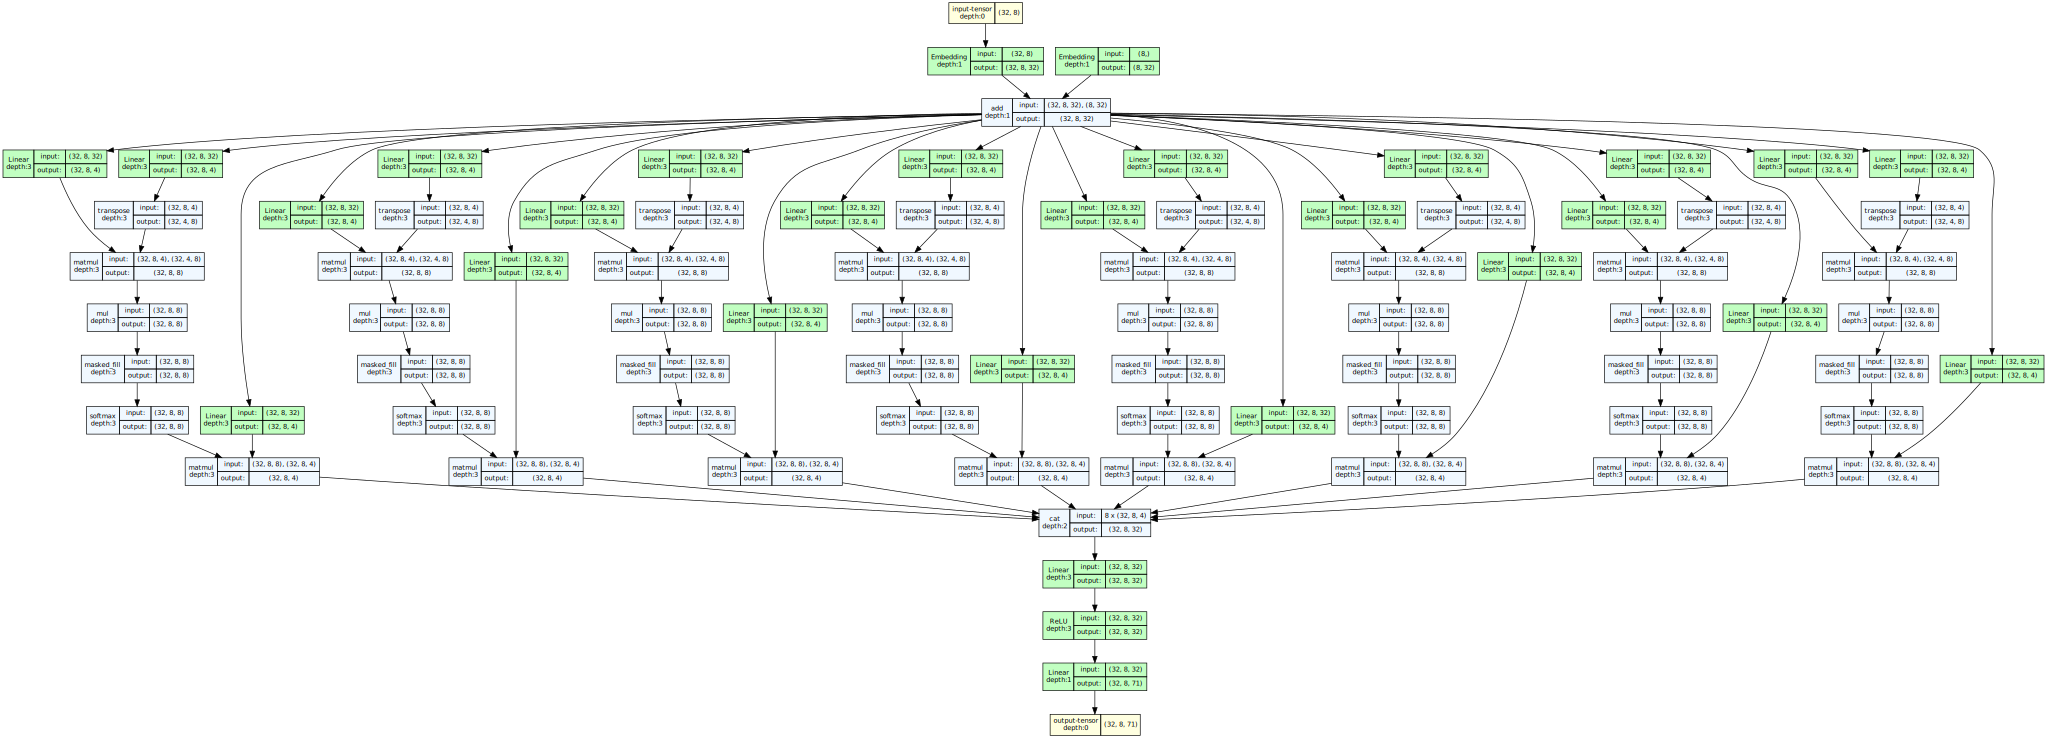

In [17]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size, emb_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

In [18]:
BigramLanguageModel(vocab_size, emb_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 32)
  (position_embedding_table): Embedding(8, 32)
  (att_head): MultiHeadAttention(
    (heads): ModuleList(
      (0-7): 8 x Head(
        (key): Linear(in_features=32, out_features=4, bias=False)
        (query): Linear(in_features=32, out_features=4, bias=False)
        (value): Linear(in_features=32, out_features=4, bias=False)
      )
    )
  )
  (feedforward): FeedForward(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (linear_head): Linear(in_features=32, out_features=71, bias=True)
)

## 12. Sanity check: untrained generation

In [19]:
model = BigramLanguageModel(vocab_size, emb_size)
model = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

0.008999 M parameters
 cE6G!□B8QmW□yCO2BmS4~E■2‘Xnl~cWQZC•pCBj3Wo7wbjI3tzGxYC‘lWDO4M?R6wJkQoNvhrBaLHvHSO0Xpqf5QoOF?TsOt5VFHbnDx83dJdcIuIQc0Ok1WGl1mMDBEh2iMor‘a1g•RZ1lTZvCGEft3kYzNUEforGEs•l7bSJ8i4G~BPdiMgcE■vSv4NPavtNnDghbd


## 13. Training the model

In [20]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.3306, val loss 4.3303
step 500: train loss 2.4693, val loss 2.4456
step 1000: train loss 2.3574, val loss 2.3350
step 1500: train loss 2.3048, val loss 2.2661
step 2000: train loss 2.2588, val loss 2.2363
step 2500: train loss 2.2312, val loss 2.1959
step 3000: train loss 2.1934, val loss 2.1820
step 3500: train loss 2.1732, val loss 2.1543
step 4000: train loss 2.1514, val loss 2.1361
step 4500: train loss 2.1467, val loss 2.1248
step 5000: train loss 2.1399, val loss 2.1070
step 5500: train loss 2.1306, val loss 2.1118
step 6000: train loss 2.1012, val loss 2.1003
step 6500: train loss 2.1001, val loss 2.0817
step 7000: train loss 2.1039, val loss 2.0818
step 7500: train loss 2.0799, val loss 2.0830
step 8000: train loss 2.0649, val loss 2.0615
step 8500: train loss 2.0754, val loss 2.0608
step 9000: train loss 2.0693, val loss 2.0543
step 9500: train loss 2.0698, val loss 2.0422
step 9999: train loss 2.0453, val loss 2.0417


## 14. Generate text from the trained model

In [21]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=2000)[0].tolist()))


##########################################
# Let's generate some Harry Potter text! #
##########################################
 mad appionty .Yop it you rell awis thir bot lumbed Ron ther upmer .Don to dould pidbeluit mamce thre shairs .The dor .Yockould of whe sightirning his to Hagragids frobchione having I then and rea mourvellilme dagrund Fly thice fiathe Uven of few his therrmsaint to Helargo jut reakemar the they shave ?Ruded for unatetacat .Honks exudn hour axctas a a lis Ronsiz Dund Ob con and furme of teR to upre lookeen Lup thated a caurts jup wand foo agits acars muminokther befilatk hally a bet crand with fre dambeall .OlF you nentoughe inf the naply gis Harry hoo Im reving a dow wouspuch ren na knosting seelch furbe plaby wopeethit ?don as now .M ?In !Lus what did Puled bexal Harry saushr to said nerminbethe dible fol dooll ?Beon suon bagid ut and ..Theet istant steyple if of am jup ap mistinne he be then his had wize . dily maggain to his les otay but thelf to han bage